In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

# Trajectories from TEUFEL tracking

### Probe file

In [2]:
FileName = "/home/lehnertu/Programming/TEUFEL/csr2d_probe.h5"
hdf = h5py.File(FileName, "r")

In [3]:
hdf.keys()

<KeysViewHDF5 ['Probe']>

In [4]:
dataset = hdf['Probe']
dataset

<HDF5 dataset "Probe": shape (2001, 1, 16), type "<f8">

In [5]:
timesteps = np.array(dataset)[:,0,0]
traj = np.array(dataset)[:,0,1:7]
traj.shape

(2001, 6)

In [6]:
hdf.close()

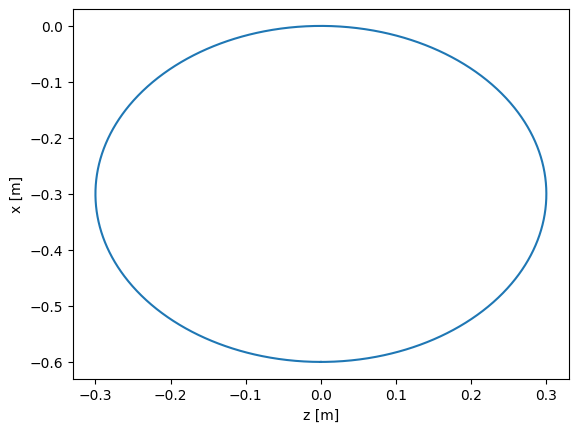

In [7]:
x = traj[:,0]
z = traj[:,2]

plt.plot(z,x)
plt.xlabel('z [m]')
plt.ylabel('x [m]')
plt.show()

In [8]:
traj[0]

array([ -0.6      ,   0.       ,   0.       ,   0.       ,   0.       ,
       -97.8424498])

In [9]:
traj[1000]

array([-2.79175794e-10,  0.00000000e+00,  3.87895555e-07, -1.26508845e-04,
        0.00000000e+00,  9.78424498e+01])

In [10]:
traj[2000]

array([-6.00000000e-01,  0.00000000e+00, -7.75791254e-07,  2.53017723e-04,
        0.00000000e+00, -9.78424498e+01])

### check length, timing and 2nd order accuracy 

In [11]:
X0 = traj[1000,0:3]
X1 = traj[1001,0:3]

In [12]:
BG0 = traj[1000,3:]
BG1 = traj[1001,3:]
BG = 0.5*(BG0+BG1)

In [13]:
Gamma = np.sqrt( np.dot(BG,BG) + 1.0)
print(Gamma)
Beta = BG/Gamma
print(Beta)

97.84743922267715
[-0.00157201  0.          0.99994654]


In [14]:
R = 0.3
L = R*2*np.pi
t = L/(np.linalg.norm(Beta)*sc.c)
dt = t / 2000
print(f'dt = {dt:.6g} s')

dt = 3.14393e-12 s


In [15]:
timesteps[1]-timesteps[0]

3.1439317258570202e-12

In [16]:
print(X0+Beta*sc.c*dt)
print(X1)

[-1.48193844e-06  0.00000000e+00  9.42864527e-04]
[-1.48193844e-06  0.00000000e+00  9.42864527e-04]


# Investigate computation warnings

In [179]:
# the snapshot is done at i=1000, so this is the time of observation
obs_time = timesteps[1000]
obs_point = np.array([0,0,-4.0e-6])
i1 = 999
X1 = traj[i1,0:3]
bg1 =  traj[i1,3:6]
bg = np.linalg.norm(bg1)
gamma = np.sqrt(bg**2+1)
print(timesteps[i1],X1,bg1/gamma)
R1 = np.linalg.norm(X1-obs_point)
t1 = obs_time - (timesteps[i1] + R1 / sc.c)
print(R1,t1)
i2 = 1000
X2 = traj[i2,0:3]
bg2 =  traj[i2,3:6]
bg = np.linalg.norm(bg1)
gamma = np.sqrt(bg**2+1)
print(timesteps[i2],X2,bg2/gamma)
R2 = np.linalg.norm(X2-obs_point)
t2 = obs_time - (timesteps[i2] + R2 / sc.c)
print(R2,t2)

3.140787794131145e-09 [-1.47950123e-06  0.00000000e+00 -9.42088740e-04] [0.00314013 0.         0.99994284]
0.0009380899062707193 1.4800617859831736e-14
3.1439317258570018e-09 [-2.79175794e-10  0.00000000e+00  3.87895555e-07] [-1.29291773e-06  0.00000000e+00  9.99947775e-01]
4.387895563635767e-06 -1.4636444134877075e-14


In [180]:
timesteps[i2]-timesteps[i1]

3.1439317258569095e-12

In [130]:
frac = t1/(t1-t2)
frac

0.5027885548663819

In [133]:
SourceT = timesteps[i1]*(1.0-frac) + timesteps[i2]*frac
SourceX = X1*(1.0-frac) + X2*frac
print(SourceT,SourceX)
R = np.linalg.norm(SourceX-obs_point)
dt = obs_time - (SourceT + R / sc.c)
print(R,dt)

3.142368527020187e-09 [-7.35765310e-07  0.00000000e+00 -4.68222274e-04]
0.0004642228572765435 1.4718063237471355e-14


In [148]:
frac = 0.99767
SourceT = timesteps[i1]*(1.0-frac) + timesteps[i2]*frac
SourceX = X1*(1.0-frac) + X2*frac
print(SourceT,SourceX)
R = np.linalg.norm(SourceX-obs_point)
dt = obs_time - (SourceT + R / sc.c)
print(R,dt)

3.1439244004960807e-09 [-3.72576317e-09  0.00000000e+00 -1.80807501e-06]
2.1919281613586957e-06 1.3875582130711084e-17


<b>The dependency of the observation time on frac is highly nonlinear.<br>
If we are close to one trajectory point there are significant changes only very near that point.</b>

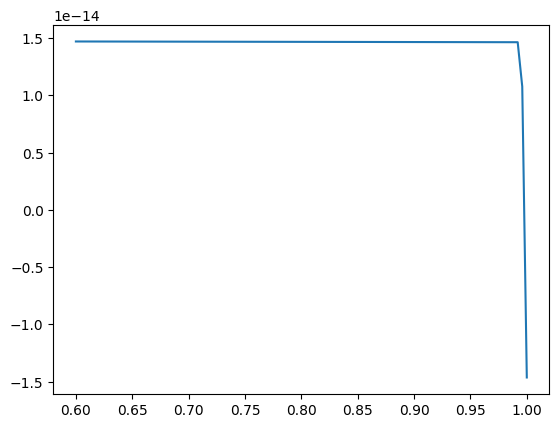

In [161]:
frac = np.linspace(0.6,1.0,100)
ObsT = []
for f in frac:
    SourceT = timesteps[i1]*(1.0-f) + timesteps[i2]*f
    SourceX = X1*(1.0-f) + X2*f
    R = np.linalg.norm(SourceX-obs_point)
    dt = obs_time - (SourceT + R / sc.c)
    ObsT.append(dt)
plt.plot(frac,ObsT)
plt.show()

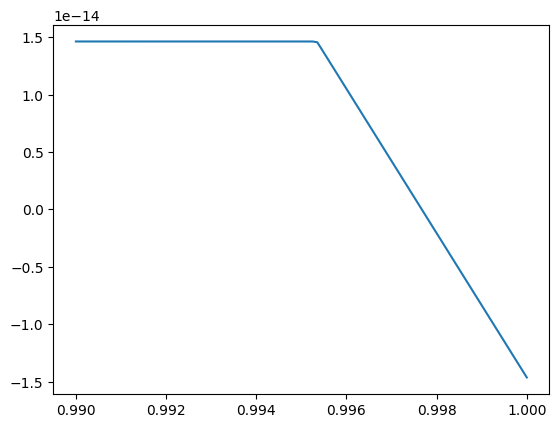

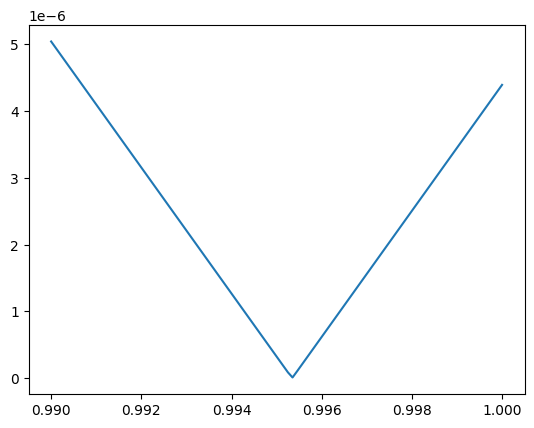

In [176]:
frac = np.linspace(0.99,1.0,100)
Dist = []
ObsT = []
for f in frac:
    SourceT = timesteps[i1]*(1.0-f) + timesteps[i2]*f
    SourceX = X1*(1.0-f) + X2*f
    R = np.linalg.norm(SourceX-obs_point)
    dt = obs_time - (SourceT + R / sc.c)
    Dist.append(R)
    ObsT.append(dt)
plt.plot(frac,ObsT)
plt.show()
plt.plot(frac,Dist)
plt.show()

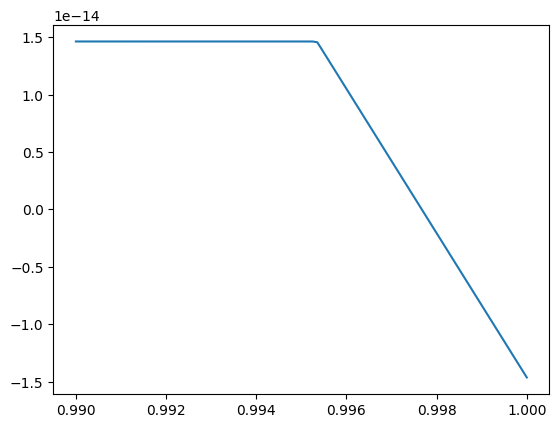

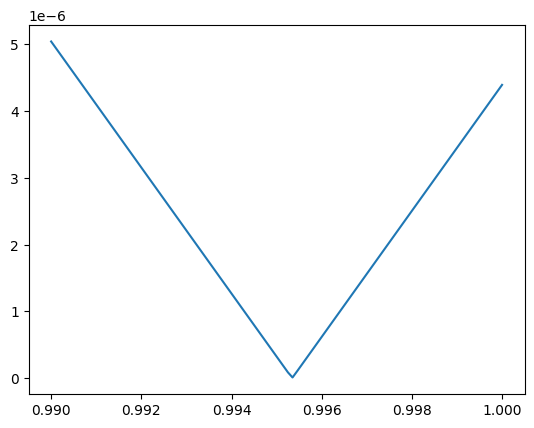

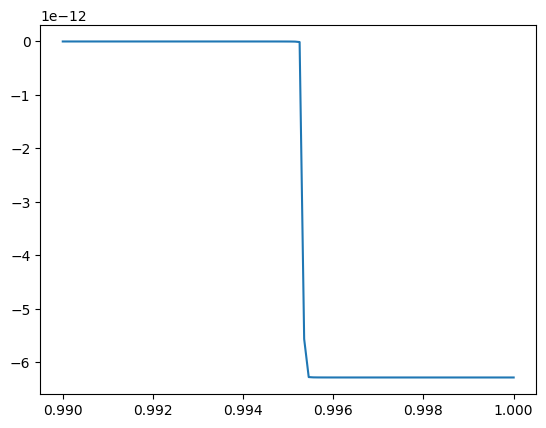

In [183]:
frac = np.linspace(0.99,1.0,100)
eps = 1e-6
Dist = []
ObsT = []
dTdf = []
for f in frac:
    SourceT = timesteps[i1]*(1.0-f) + timesteps[i2]*f
    SourceTp = timesteps[i1]*(1.0-(f+eps)) + timesteps[i2]*(f+eps)
    SourceTm = timesteps[i1]*(1.0-(f-eps)) + timesteps[i2]*(f-eps)
    SourceX = X1*(1.0-f) + X2*f
    SourceXp = X1*(1.0-(f+eps)) + X2*(f+eps)
    SourceXm = X1*(1.0-(f-eps)) + X2*(f-eps)
    R = np.linalg.norm(SourceX-obs_point)
    Rp = np.linalg.norm(SourceXp-obs_point)
    Rm = np.linalg.norm(SourceXm-obs_point)
    dt = obs_time - (SourceT + R / sc.c)
    Dist.append(R)
    ObsT.append(dt)
    dTdf.append((SourceTm-SourceTp)/(2*eps)+(Rm-Rp)/(2*eps*sc.c))
plt.plot(frac,ObsT)
plt.show()
plt.plot(frac,Dist)
plt.show()
plt.plot(frac,dTdf)
plt.show()

In [184]:
# the snapshot is done at i=1000, so this is the time of observation
obs_time = timesteps[1000]
obs_point = np.array([-0.0001,0,-2.0e-5])
i1 = 999
X1 = traj[i1,0:3]
print(timesteps[i1],X1)
R1 = np.linalg.norm(X1-obs_point)
t1 = obs_time - (timesteps[i1] + R1 / sc.c)
print(R1,t1)
i2 = 1000
X2 = traj[i2,0:3]
print(timesteps[i2],X2)
R2 = np.linalg.norm(X2-obs_point)
t2 = obs_time - (timesteps[i2] + R2 / sc.c)
print(R2,t2)

3.140787794131145e-09 [-1.47950123e-06  0.00000000e+00 -9.42088740e-04]
0.0009273370111965414 5.066841502154874e-14
3.1439317258570018e-09 [-2.79175794e-10  0.00000000e+00  3.87895555e-07]
0.00010205689810135725 -3.4042516873921175e-13


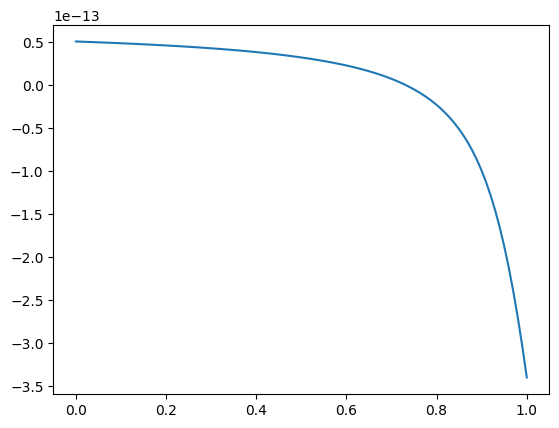

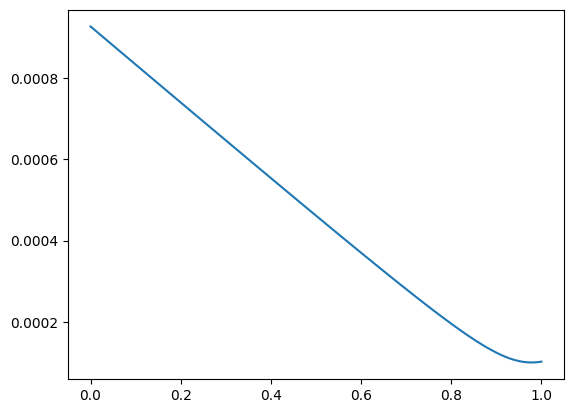

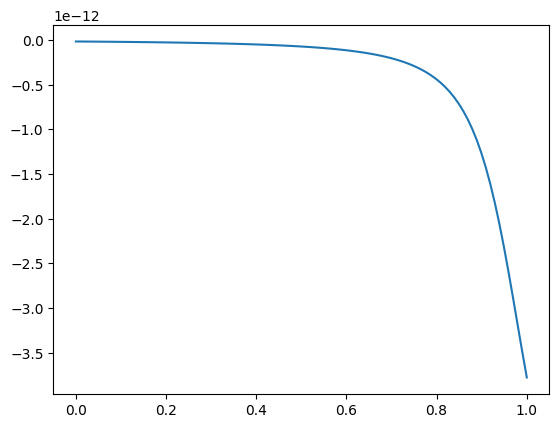

In [185]:
frac = np.linspace(0.0,1.0,100)
eps = 1e-6
Dist = []
ObsT = []
dTdf = []
for f in frac:
    SourceT = timesteps[i1]*(1.0-f) + timesteps[i2]*f
    SourceTp = timesteps[i1]*(1.0-(f+eps)) + timesteps[i2]*(f+eps)
    SourceTm = timesteps[i1]*(1.0-(f-eps)) + timesteps[i2]*(f-eps)
    SourceX = X1*(1.0-f) + X2*f
    SourceXp = X1*(1.0-(f+eps)) + X2*(f+eps)
    SourceXm = X1*(1.0-(f-eps)) + X2*(f-eps)
    R = np.linalg.norm(SourceX-obs_point)
    Rp = np.linalg.norm(SourceXp-obs_point)
    Rm = np.linalg.norm(SourceXm-obs_point)
    dt = obs_time - (SourceT + R / sc.c)
    Dist.append(R)
    ObsT.append(dt)
    dTdf.append((SourceTm-SourceTp)/(2*eps)+(Rm-Rp)/(2*eps*sc.c))
plt.plot(frac,ObsT)
plt.show()
plt.plot(frac,Dist)
plt.show()
plt.plot(frac,dTdf)
plt.show()

<b>A refinement of the retardation point should use a Newton algorithm starting from the last point of the interval,
because the derivative of the observation time with respect to the fraction is highest
when the particle has already passed the observation point and very low while it is approaching.</b>

# Snapshot from TEUFEL tracking

In [88]:
FileName = "/home/lehnertu/Programming/TEUFEL/csr2d_snap_1000.h5"

# open the file
hdf = h5py.File(FileName, "r")
print(hdf)
print(hdf.keys())
# Get the groups
pos_group = hdf['ObservationPosition']
Nx = pos_group.attrs.get('Nx')
Ny = pos_group.attrs.get('Ny')
print(pos_group)
print("Nx=%d Ny=%d" % (Nx,Ny))
field_group = hdf['ElMagField']
print(field_group)
par_group = hdf['ParticleCoordinates']
N_par = par_group.attrs.get('N_particles')
print(par_group)
print("Npart=%d" % N_par)
# get the data
pos = np.array(pos_group)
A = np.array(field_group)
coo = np.array(par_group)
hdf.close()

<HDF5 file "csr2d_snap_1000.h5" (mode r)>
<KeysViewHDF5 ['ElMagField', 'ObservationPosition', 'ParticleCoordinates']>
<HDF5 dataset "ObservationPosition": shape (101, 251, 3), type "<f8">
Nx=101 Ny=251
<HDF5 dataset "ElMagField": shape (101, 251, 6), type "<f8">
<HDF5 dataset "ParticleCoordinates": shape (5, 6), type "<f8">
Npart=5


In [89]:
Ex = A[:,:,0]
Ey = A[:,:,1]
Ez = A[:,:,2]
Bx = A[:,:,3]
By = A[:,:,4]
Bz = A[:,:,5]

In [90]:
x_part = 1e3*coo[:,0]
z_part = 1e3*coo[:,2]
print(x_part)
print(z_part)

[-2.79175802e-07 -1.00000028e+00  9.99999721e-01 -2.79175802e-07
 -2.79175802e-07]
[ 0.0003879  0.0003879  0.0003879 -0.1996121  0.2003879]


In [91]:
print(pos.shape)
x = 1e3*pos[:,:,0]
print(np.min(x), np.max(x))
z = 1e3*pos[:,:,2]
print(np.min(z), np.max(z))

(101, 251, 3)
-2.5 2.5
-0.25 0.25


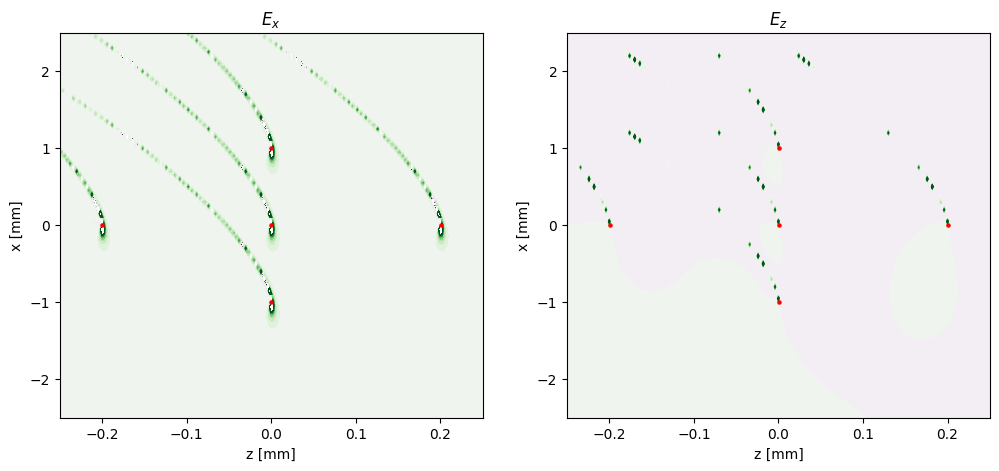

In [92]:
emax = 2e10
elevels = np.linspace(-emax, emax, num=21)

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1.contourf(z,x,Ex,elevels,cmap='PRGn')
ax1.set_xlabel('z [mm]')
ax1.set_ylabel('x [mm]')
ax1.scatter(z_part,x_part,c='r',s=5)
ax1.set_title('$E_x$')
ax2.contourf(z,x,Ez,elevels,cmap='PRGn')
ax2.set_xlabel('z [mm]')
ax2.set_ylabel('x [mm]')
ax2.scatter(z_part,x_part,c='r',s=5)
ax2.set_title('$E_z$')
plt.show()

# Read stored field maps

In [98]:
FileName = "/home/lehnertu/Programming/TEUFEL/csr2d_interaction_fields.hdf5"
hdf = h5py.File(FileName, "r")

In [99]:
hdf.keys()

<KeysViewHDF5 ['Fields', 'Geometry', 'Particles']>

In [100]:
dataset = hdf['Geometry']
dataset

<HDF5 dataset "Geometry": shape (20, 3, 3), type "<f8">

In [101]:
particles = hdf['Particles']
particles

<HDF5 dataset "Particles": shape (20, 5, 6), type "<f8">

In [102]:
for att in dataset.attrs: print(att)

N_long
N_steps
N_trans


In [103]:
for att in particles.attrs: print(att)

NOP


In [104]:
fields = hdf['Fields']
for att in fields.attrs: print(f'{att} = {fields.attrs[att]}')
field_data = np.array(fields)
print(field_data.shape)

NOS = 20
N_long = 100
N_trans = 20
(20, 100, 20, 6)


In [105]:
N_steps = dataset.attrs['N_steps']
N_long = dataset.attrs['N_long']
N_trans = dataset.attrs['N_trans']
(N_steps, N_long, N_trans)

(20, 100, 20)

In [106]:
origin = np.array(dataset)[:,0,:]
d_long = np.array(dataset)[:,1,:]
d_trans = np.array(dataset)[:,2,:]
origin

array([[-5.98800000e-01,  0.00000000e+00,  2.40000000e-04],
       [-5.84346123e-01,  0.00000000e+00, -9.19997926e-02],
       [-5.42334233e-01,  0.00000000e+00, -1.75194370e-01],
       [-4.76706303e-01,  0.00000000e+00, -2.41563899e-01],
       [-3.93675772e-01,  0.00000000e+00, -2.84611661e-01],
       [-3.01199806e-01,  0.00000000e+00, -2.99760001e-01],
       [-2.08494681e-01,  0.00000000e+00, -2.85316883e-01],
       [-1.24864205e-01,  0.00000000e+00, -2.42704939e-01],
       [-5.84947195e-02,  0.00000000e+00, -1.76335325e-01],
       [-1.58829375e-02,  0.00000000e+00, -9.27047662e-02],
       [-1.19999997e-03,  0.00000000e+00, -2.39613656e-04],
       [-1.56539956e-02,  0.00000000e+00,  9.20001590e-02],
       [-5.76659924e-02,  0.00000000e+00,  1.75194683e-01],
       [-1.23294008e-01,  0.00000000e+00,  2.41564128e-01],
       [-2.06324595e-01,  0.00000000e+00,  2.84611784e-01],
       [-2.98800582e-01,  0.00000000e+00,  2.99760002e-01],
       [-3.91505689e-01,  0.00000000e+00

In [107]:
coo = np.array(particles)
coo.shape

(20, 5, 6)

In [108]:
hdf.close()

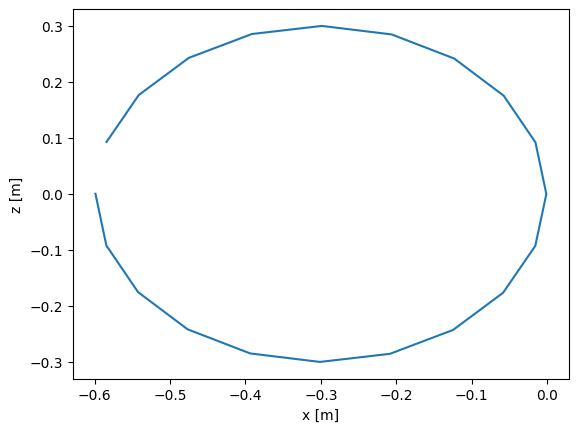

In [109]:
x = origin[:,0]
z = origin[:,2]

plt.plot(x,z)
plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.show()

In [110]:
step = 7
O = origin[step,(0,2)]
dl = d_long[step,(0,2)]
dt = d_trans[step,(0,2)]
print(O)
print(dl)
print(dt)

[-0.1248642  -0.24270494]
[1.58668518e-05 1.15279646e-05]
[ 4.36411407e-05 -6.00667627e-05]


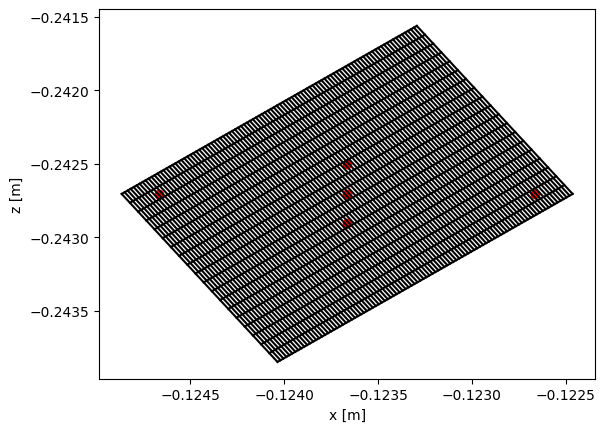

In [111]:
for i in range(N_trans):
    arr = np.array([O+i*dt,O+i*dt+(N_long-1)*dl])
    plt.plot(arr[:,0],arr[:,1], 'k-')
for i in range(N_long):
    arr = np.array([O+i*dl,O+i*dl+(N_trans-1)*dt])
    plt.plot(arr[:,0],arr[:,1], 'k-')
plt.scatter(coo[step,:,0], coo[step,:,2], color='red')
plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.show()

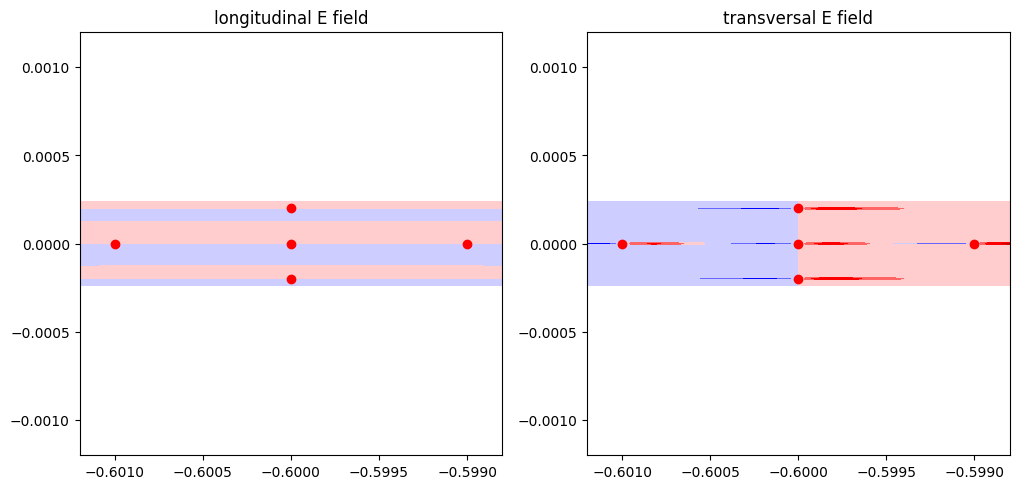

In [142]:
step=0
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

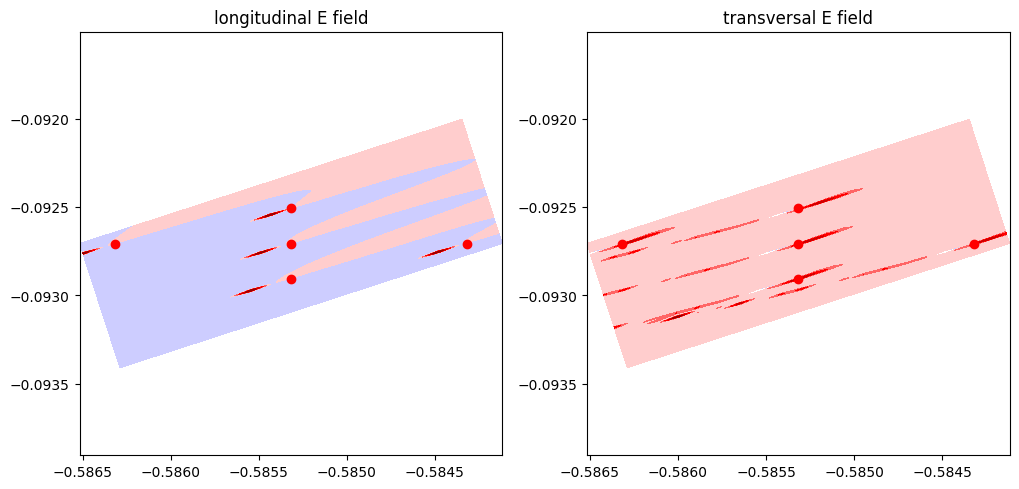

In [143]:
step=1
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

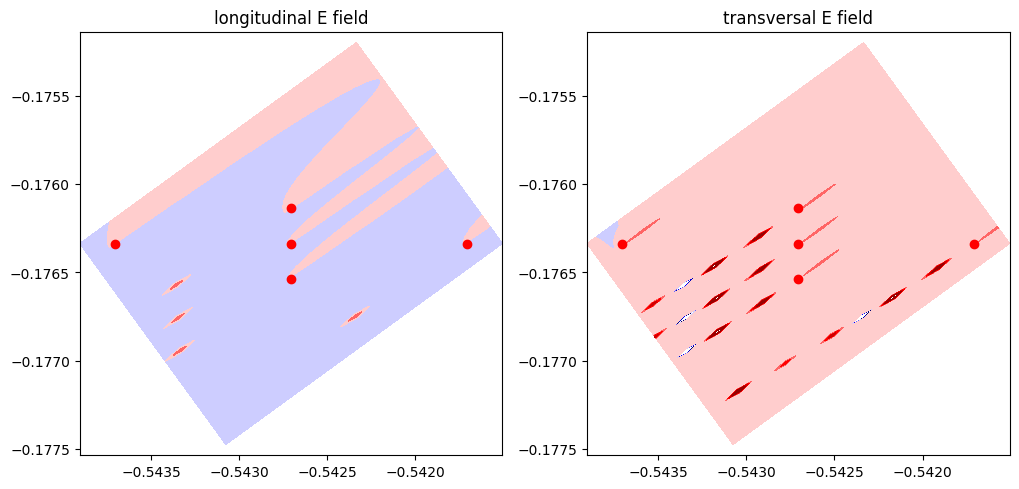

In [144]:
step=2
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

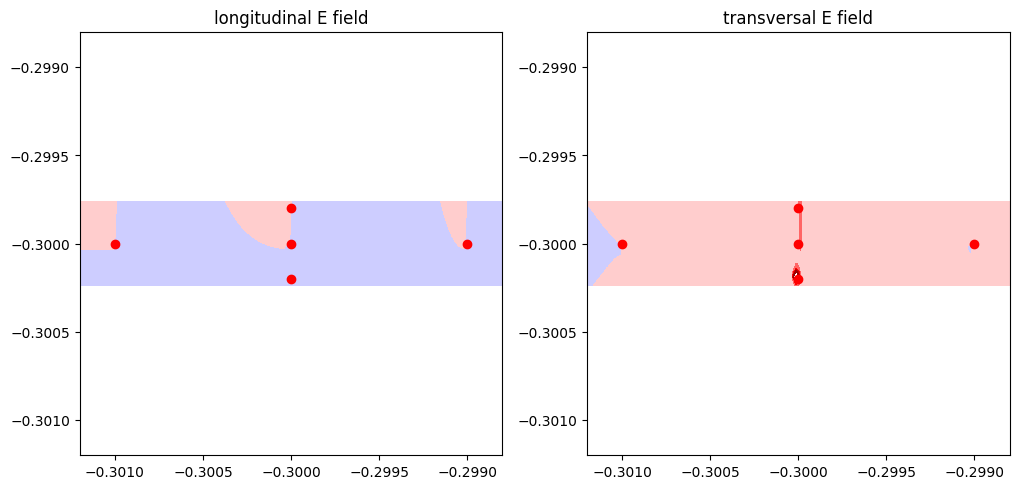

In [145]:
step=5
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

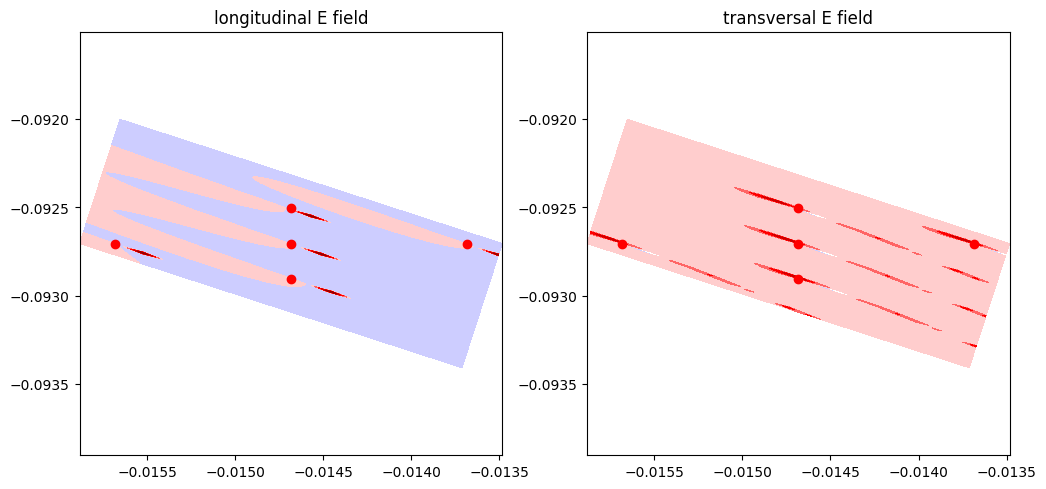

In [146]:
step=9
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

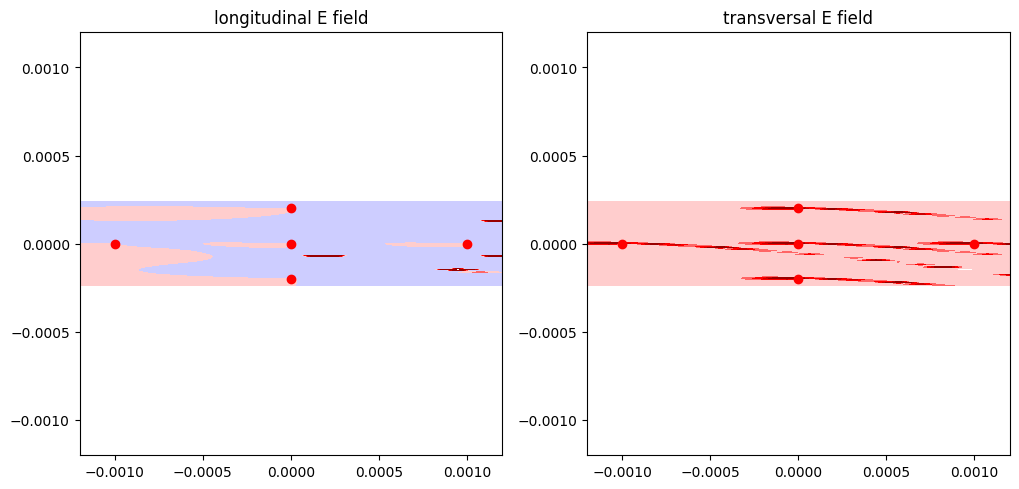

In [147]:
step=10
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

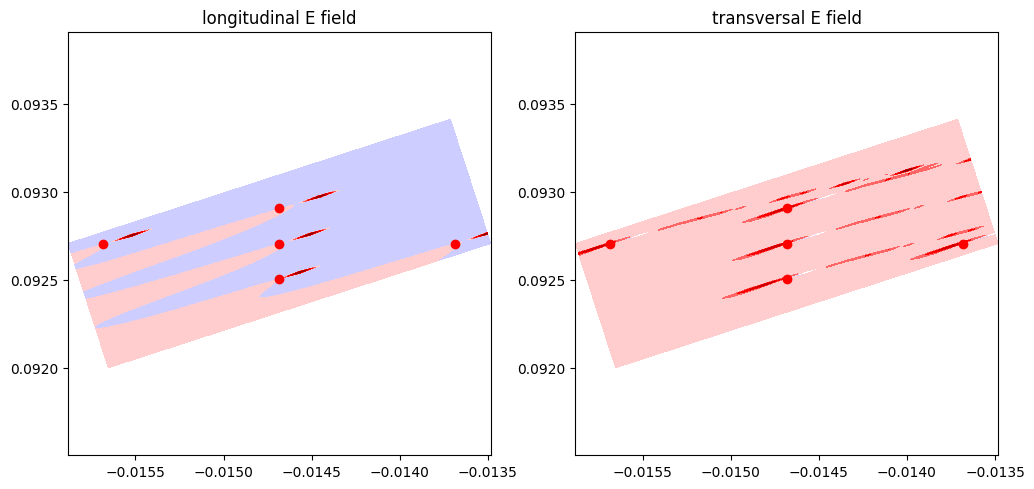

In [141]:
step=11
O=origin[step]
dl=d_long[step]
e_long = dl/np.linalg.norm(dl)
dt=d_trans[step]
e_trans = dt/np.linalg.norm(dt)

i, j = np.meshgrid(np.arange(N_long), np.arange(N_trans), indexing='ij')
grid = i[..., np.newaxis] * dl + j[..., np.newaxis] * dt + O
X = grid[:,:,0]
Z = grid[:,:,2]

fmap = field_data[step]
E = fmap[:,:,0:3]
E_long = np.dot(E,e_long)
E_trans = np.dot(E,e_trans)

elevels = np.linspace(-1e10, 1e10, num=11)
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(X,Z,E_long,elevels,cmap='seismic')
ax1.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax1.axis("equal")
ax1.set_title("longitudinal E field")
ax2.contourf(X,Z,E_trans,elevels,cmap='seismic')
ax2.scatter(coo[step,:,0], coo[step,:,2], color='red')
ax2.axis("equal")
ax2.set_title("transversal E field")
plt.show()

In [68]:
E=fmap[:,:,0:3]
E.shape

(100, 20, 3)

In [69]:
dl

array([-6.26901941e-12,  0.00000000e+00,  4.84848485e-06])

In [72]:
E_long = np.dot(E,dl)
E_long.shape

(100, 20)